# Question 1: PCA For Network Intrusion Detection

In [ ]:
# Eva

# Question 2: Your Own Personal Netflix

In [1]:
# Anusha

from pathlib import Path
import numpy as np
import pandas as pd


def load_ratings_data_pandas(data_dir="ml-latest-small/"):
    """Load data using pandas dataframes."""
    data_dir = Path(data_dir)
    assert data_dir.exists(), f"{data_dir} does not exist"

    return pd.read_csv(data_dir / 'ratings.csv',sep=',')


def load_movies_data_pandas(data_dir="ml-latest-small/"):
    """Load data using pandas dataframes."""
    data_dir = Path(data_dir)
    assert data_dir.exists(), f"{data_dir} does not exist"
    return pd.read_csv(data_dir / 'movies.csv')


def filter_data(ratings_data: pd.DataFrame, movies_data: pd.DataFrame):
    """Filter data. Too few ratings prevent effective use of matrix completion."""
    ratings_data = ratings_data.pivot(
        index='userId',
        columns='movieId',
        values='rating'
    ).fillna(0)

    keep_movie = (ratings_data != 0).sum(axis=0) > 100
    ratings_data = ratings_data.loc[:, keep_movie]

    # Filter movies_data by movieId (columns of ratings_data after filtering)
    movies_data = movies_data[movies_data['movieId'].isin(ratings_data.columns)]

    keep_user = (ratings_data != 0).sum(axis=1) >= 5
    ratings_data = ratings_data.loc[keep_user, :]

    return ratings_data, movies_data


def print_data_summary(ratings: pd.DataFrame):
    n_users = ratings.shape[0]
    n_movies = ratings.shape[1]
    n_ratings = (ratings != 0).sum().sum()
    density = n_ratings / (n_users * n_movies)

    print(f"Dataset Summary")
    print(f"----------------")
    print(f"Users: {n_users}")
    print(f"Movies: {n_movies}")
    print(f"Total Ratings: {n_ratings}")
    print(f"Data Density: {density:.4f} (fraction of observed ratings)")


def load_ratings_data(data_dir="ml-latest-small/", print_summary=False):
    """Load data in numpy format."""
    ratings, movies = filter_data(
        load_ratings_data_pandas(data_dir=data_dir),
        load_movies_data_pandas(data_dir=data_dir)
    )
    if print_summary:
        print_data_summary(ratings)
    return ratings.to_numpy()


def matrix_completion(D, n_features, n_movies, n_users, t_max=100, lambd=0.1):
    np.random.seed(0)
    X = np.random.normal(size=(n_movies, n_features))
    Y = np.random.normal(size=(n_users, n_features))

    # Implementation the optimization procedure here
    raise NotImplementedError

    return X, Y

In [20]:
ratings = load_ratings_data("ml-latest-small", print_summary=True)
ratings

Dataset Summary
----------------
Users: 556
Movies: 134
Total Ratings: 19694
Data Density: 0.2643 (fraction of observed ratings)


array([[4. , 0. , 4. , ..., 0. , 0. , 0. ],
       [0. , 0. , 0. , ..., 0. , 0. , 4. ],
       [0. , 0. , 0. , ..., 0. , 0. , 0. ],
       ...,
       [2.5, 2. , 0. , ..., 0. , 0. , 0. ],
       [3. , 0. , 0. , ..., 0. , 0. , 0. ],
       [5. , 0. , 5. , ..., 4.5, 3.5, 4. ]])

# Question 3: Image Classification With Neural Networks

### Template code for providing definitions

In [7]:
"""
CNN Embedding Space Visualization

This educational module demonstrates:
- ResNet-style architecture with skip connections
- Embedding space learning for visualization
- Domain transfer between MNIST and Fashion-MNIST
- Decision boundary visualization
"""

from dataclasses import dataclass
from pathlib import Path
from typing import Tuple, Optional, Callable
import time

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.offsetbox import OffsetImage, AnnotationBbox

# Extra import for progress bars while training
from tqdm import tqdm

@dataclass
class Config:
    """Configuration parameters for the model and training."""

    # Model architecture
    embedding_dim: int = 2
    num_classes: int = 10

    # Training hyperparameters
    learning_rate: float = 0.9 
    momentum: float = 0.9
    weight_decay: float = 5e-4
    batch_size: int = 128
    epochs: int = 5
    dropout_rate_1: float = 0.9
    dropout_rate_2: float = 0.9

    # Visualization
    viz_samples: int = 100
    viz_zoom: float = 0.7
    grid_resolution: float = 0.1 
    
    # Paths
    checkpoint_dir: Path = Path("checkpoint")
    model_filename: str = "embedding_model.pth"

    @property
    def device(self) -> str:
        """Get the appropriate device for computation."""
        return 'cuda' if torch.cuda.is_available() else 'cpu'


class ResidualBlock(nn.Module):
    """
    Residual block with skip connections and grouped convolutions.

    Implements: output = input + F(input)
    where F is a residual function composed of BatchNorm→ReLU→Conv layers.
    """

    def __init__(self, in_channels: int, out_channels: int, kernel_size: int, groups: int = 1):
        super().__init__()

        groups = min(groups, min(in_channels, out_channels))

        # Main convolution pathway
        self.conv1 = nn.Conv2d(in_channels, out_channels, kernel_size,
                              padding="same", groups=groups)
        self.conv2 = nn.Conv2d(out_channels, out_channels, kernel_size,
                              padding="same", groups=min(groups, out_channels))

        # Skip connection (identity or dimension adjustment)
        self.skip_connection = (
            nn.Identity() if in_channels == out_channels
            else nn.Conv2d(in_channels, out_channels, kernel_size=1, padding="same")
        )

        # Pre-activation normalization layers
        self.norm1 = nn.BatchNorm2d(in_channels)
        self.norm2 = nn.BatchNorm2d(out_channels)

        self.relu = nn.ReLU(inplace=True)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass implementing residual connection."""
        identity = self.skip_connection(x)

        # Residual pathway: BatchNorm → ReLU → Conv → BatchNorm → ReLU → Conv
        out = self.conv1(self.relu(self.norm1(x)))
        out = self.conv2(self.relu(self.norm2(out)))

        return identity + out


class EmbeddingNetwork(nn.Module):
    """
    CNN that maps input images to low-dimensional embedding space.

    Uses global average pooling instead of flattening to reduce overfitting
    and make the model robust to different input sizes.
    """

    def __init__(self, embedding_dim: int, dropout_rate_1: float, dropout_rate_2: float):
        super().__init__()

        # Initial feature extraction
        self.initial_conv = nn.Conv2d(1, 32, kernel_size=5, padding="same")
        self.initial_norm = nn.BatchNorm2d(32)

        # First residual block set (32 channels, groups=2)
        self.res_block1 = ResidualBlock(32, 32, kernel_size=3, groups=2)
        self.res_block2 = ResidualBlock(32, 32, kernel_size=3, groups=2)

        # Spatial downsampling
        self.pool = nn.MaxPool2d(2)
        self.norm_after_pool = nn.BatchNorm2d(32)

        # Second residual block set (64 channels, groups=4)
        self.res_block3 = ResidualBlock(32, 64, kernel_size=3, groups=4)
        self.res_block4 = ResidualBlock(64, 64, kernel_size=3, groups=4)

        # Final processing
        self.final_norm = nn.BatchNorm1d(64)
        self.fc1 = nn.Linear(64, 128)
        self.fc2 = nn.Linear(128, embedding_dim)

        # Regularization
        self.dropout1 = nn.Dropout(dropout_rate_1)
        self.dropout2 = nn.Dropout(dropout_rate_2)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """
        Forward pass mapping images to embedding space.

        Args:
            x: Input tensor of shape (batch_size, 1, 28, 28)

        Returns:
            Embedding tensor of shape (batch_size, embedding_dim)
        """
        out = F.relu(self.initial_norm(self.initial_conv(x)))

        # First round of residual blocks
        out = self.res_block2(self.res_block1(out))

        # Pooling
        out = self.norm_after_pool(self.pool(out))

        # Second round of residual blocks
        out = self.res_block4(self.res_block3(out))

        # Global average pooling
        out = torch.mean(out, dim=(-1, -2))
        out = self.final_norm(out)

        # Map to embedding space
        out = self.dropout1(out)
        out = F.relu(self.fc1(out))
        out = self.dropout2(out)
        out = self.fc2(out)

        return out


class EmbeddingClassifier(nn.Module):
    """Complete model combining embedding network with classifier."""

    def __init__(self, embedding_dim: int, num_classes: int, config: Config):
        super().__init__()
        self.embedding_net = EmbeddingNetwork(
            embedding_dim, config.dropout_rate_1, config.dropout_rate_2
        )
        self.classifier = nn.Linear(embedding_dim, num_classes, bias=True)

        nn.init.normal_(self.classifier.weight, 0, 0.01)
        nn.init.constant_(self.classifier.bias, 0)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        """Forward pass for training and evaluation."""
        embeddings = self.embedding_net(x)
        return self.classifier(embeddings)

    def get_embeddings(self, x: torch.Tensor) -> torch.Tensor:
        """Extract embeddings for visualization."""
        return self.embedding_net(x)

    def get_probabilities(self, x: torch.Tensor) -> torch.Tensor:
        """Get class probabilities for confidence visualization."""
        embeddings = self.embedding_net(x)
        return F.softmax(self.classifier(embeddings), dim=1)


def create_data_loaders(dataset_class, config: Config) -> Tuple[DataLoader, DataLoader]:
    """
    Create training and test data loaders.

    Args:
        dataset_class: torchvision dataset class (MNIST or FashionMNIST)
        config: Configuration object

    Returns:
        Tuple of (train_loader, test_loader)
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.1307,), (0.3081,))  # MNIST standard values
    ])

    # Training data
    train_dataset = dataset_class(root='./data', train=True, download=True, transform=transform)
    if config.num_classes < 10:
        mask = train_dataset.targets < config.num_classes
        train_dataset.targets = train_dataset.targets[mask]
        train_dataset.data = train_dataset.data[mask]

    train_loader = DataLoader(
        train_dataset, batch_size=config.batch_size, shuffle=True, num_workers=2
    )

    # Test data
    test_dataset = dataset_class(root='./data', train=False, download=True, transform=transform)
    if config.num_classes < 10:
        mask = test_dataset.targets < config.num_classes
        test_dataset.targets = test_dataset.targets[mask]
        test_dataset.data = test_dataset.data[mask]

    test_loader = DataLoader(
        test_dataset, batch_size=config.batch_size, shuffle=False, num_workers=2
    )

    return train_loader, test_loader


@dataclass
class EpochMetrics:
    """Container for epoch training/evaluation metrics."""
    accuracy: float
    avg_confidence: float
    avg_loss: float
    total_samples: int
    elapsed_time: Optional[float] = None


def compute_batch_metrics(logits: torch.Tensor, targets: torch.Tensor, loss: torch.Tensor) -> Tuple[int, float, int]:
    """
    Compute metrics for a single batch.

    Args:
        logits: Model output logits
        targets: Ground truth labels
        loss: Computed loss for the batch

    Returns:
        Tuple of (correct_predictions, total_confidence, batch_size)
    """
    probabilities = F.softmax(logits, dim=1)
    confidences, predictions = probabilities.max(1)

    correct_predictions = predictions.eq(targets).sum().item()
    total_confidence = confidences.sum().item()
    batch_size = targets.size(0)

    return correct_predictions, total_confidence, batch_size


def run_epoch(
    model: nn.Module,
    criterion,
    data_loader: DataLoader,
    device: str,
    optimizer=None,
    is_training: bool = True
) -> EpochMetrics:
    """
    Run one epoch of training or evaluation.

    Args:
        model: PyTorch model
        criterion: Loss function
        data_loader: Data loader
        device: Device to run on
        optimizer: Optimizer (required if is_training=True)
        is_training: Whether to run in training mode

    Returns:
        EpochMetrics containing all computed metrics
    """
    if is_training:
        if optimizer is None:
            raise ValueError("Optimizer required for training mode")
        model.train()
    else:
        model.eval()

    total_loss = 0.0
    total_correct = 0
    total_confidence = 0.0
    total_samples = 0

    start_time = time.time()
    context_manager = torch.no_grad() if not is_training else torch.enable_grad()

    with context_manager:
        for inputs, targets in data_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            if is_training:
                optimizer.zero_grad()

            logits = model(inputs)
            loss = criterion(logits, targets)

            if torch.isnan(loss):
                print("Warning: NaN loss detected")

            if is_training:
                loss.backward()
                optimizer.step()

            # Compute batch metrics (always without gradients for metrics)
            with torch.no_grad():
                batch_correct, batch_confidence, batch_size = compute_batch_metrics(logits, targets, loss)

                total_loss += loss.item()
                total_correct += batch_correct
                total_confidence += batch_confidence
                total_samples += batch_size

    # Calculate final metrics
    if total_samples == 0:
        print("Warning: No samples processed")
        return EpochMetrics(0, 0, float('inf'), 0, time.time() - start_time)

    accuracy = 100.0 * total_correct / total_samples
    avg_confidence = 100.0 * total_confidence / total_samples
    avg_loss = total_loss / len(data_loader)
    elapsed_time = time.time() - start_time

    return EpochMetrics(
        accuracy=accuracy,
        avg_confidence=avg_confidence,
        avg_loss=avg_loss,
        total_samples=total_samples,
        elapsed_time=elapsed_time
    )


def train_epoch(model: nn.Module, criterion, optimizer, data_loader: DataLoader, device: str) -> Tuple[float, float]:
    """
    Train model for one epoch.

    Returns:
        Tuple of (accuracy, average_confidence)
    """
    metrics = run_epoch(model, criterion, data_loader, device, optimizer, is_training=True)

    print(f'Train - Loss: {metrics.avg_loss:.3f} | '
          f'Acc: {metrics.accuracy:.3f}% ({int(metrics.accuracy * metrics.total_samples / 100)}/{metrics.total_samples}) | '
          f'Conf: {metrics.avg_confidence:.2f}% | Time: {metrics.elapsed_time:.2f}s')

    return metrics.accuracy, metrics.avg_confidence


def evaluate_model(model: nn.Module, criterion, data_loader: DataLoader, device: str) -> Tuple[float, float]:
    """
    Evaluate model on test data.

    Returns:
        Tuple of (accuracy, average_confidence)
    """
    metrics = run_epoch(model, criterion, data_loader, device, optimizer=None, is_training=False)

    print(f'Test  - Loss: {metrics.avg_loss:.3f} | '
          f'Acc: {metrics.accuracy:.3f}% ({int(metrics.accuracy * metrics.total_samples / 100)}/{metrics.total_samples}) | '
          f'Conf: {metrics.avg_confidence:.2f}%')

    return metrics.accuracy, metrics.avg_confidence


def save_model(model: nn.Module, accuracy: float, config: Config) -> None:
    """Save model checkpoint."""
    config.checkpoint_dir.mkdir(exist_ok=True)

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'accuracy': accuracy,
        'config': {
            'embedding_dim': config.embedding_dim,
            'num_classes': config.num_classes,
            'dropout_rate_1': config.dropout_rate_1,
            'dropout_rate_2': config.dropout_rate_2,
        }
    }

    save_path = config.checkpoint_dir / config.model_filename
    torch.save(checkpoint, save_path)
    print(f"Model saved to {save_path}")


def load_model(config: Config) -> EmbeddingClassifier:
    """Load model from checkpoint."""
    load_path = config.checkpoint_dir / config.model_filename

    model = EmbeddingClassifier(config.embedding_dim, config.num_classes, config)
    checkpoint = torch.load(load_path, map_location='cpu')
    model.load_state_dict(checkpoint['model_state_dict'])
    model.eval()

    print(f"Model loaded from {load_path}")
    print(f"Loaded model accuracy: {checkpoint['accuracy']:.2f}%")

    return model


def plot_decision_boundary(
    model: EmbeddingClassifier,
    bounds: Tuple[float, float, float, float],
    config: Config,
    show_classes: bool = False
) -> None:
    """
    Plot decision boundary or confidence map in embedding space.

    Args:
        model: Trained model
        bounds: (x_min, x_max, y_min, y_max) for plot region
        config: Configuration object
        show_classes: If True, show class assignments; if False, show confidence
    """
    x_min, x_max, y_min, y_max = bounds

    if not all(np.isfinite([x_min, x_max, y_min, y_max])):
        print("Warning: Invalid bounds detected, using default range")
        x_min, x_max, y_min, y_max = -10, 10, -10, 10

    if x_max <= x_min:
        x_max = x_min + 10
    if y_max <= y_min:
        y_max = y_min + 10

    x = np.arange(x_min, x_max, config.grid_resolution, dtype=np.float32)
    y = np.arange(y_min, y_max, config.grid_resolution, dtype=np.float32)

    if len(x) == 0 or len(y) == 0:
        print("Warning: Empty grid, adjusting resolution")
        x = np.linspace(x_min, x_max, 50, dtype=np.float32)
        y = np.linspace(y_min, y_max, 50, dtype=np.float32)

    xx, yy = np.meshgrid(x, y)

    # Create grid points for evaluation
    grid_points = torch.from_numpy(
        np.array([xx.ravel(), yy.ravel()]).T
    ).float().to(config.device)

    # Get model predictions
    with torch.no_grad():
        probabilities = torch.softmax(model.classifier(grid_points), dim=1)
        probabilities = probabilities.cpu().numpy()

    # Reshape for contour plotting
    if show_classes:
        class_assignments = probabilities.argmax(axis=1).reshape(xx.shape)
        plt.contourf(xx, yy, class_assignments, levels=config.num_classes, cmap='tab10', alpha=0.7)
        plt.colorbar(label='Predicted Class')
    else:
        confidence_map = probabilities.max(axis=1).reshape(xx.shape)
        contour = plt.contourf(xx, yy, confidence_map, levels=20, cmap='viridis', alpha=0.7)
        plt.clim(0, 1)
        plt.colorbar(contour, label='Max Confidence')

    plt.axis('equal')


def scatter_images_on_embeddings(
    images: torch.Tensor,
    embeddings: torch.Tensor,
    config: Config
) -> None:
    """
    Scatter actual images at their embedding coordinates.

    Args:
        images: Input images tensor
        embeddings: Corresponding embedding coordinates
        config: Configuration object
    """
    num_samples = min(images.shape[0], config.viz_samples)

    for i in range(num_samples):
        image = images[i].squeeze().cpu().numpy()
        embedding_pos = (embeddings[i, 0].item(), embeddings[i, 1].item())

        if not all(np.isfinite(embedding_pos)):
            continue

        offset_image = OffsetImage(image, cmap="gray", zoom=config.viz_zoom)
        annotation_box = AnnotationBbox(
            offset_image, embedding_pos, xycoords='data', frameon=False, alpha=0.7
        )
        plt.gca().add_artist(annotation_box)


def visualize_embedding_space(
    model: EmbeddingClassifier,
    data_loader: DataLoader,
    config: Config,
    title: str = "Embedding Space Visualization"
) -> None:
    """
    Create comprehensive visualization of embedding space.

    Args:
        model: Trained model
        data_loader: Data loader for visualization
        config: Configuration object
        title: Plot title
    """
    model.eval()

    # Get batch of data and embeddings
    inputs, _ = next(iter(data_loader))
    inputs = inputs.to(config.device)

    with torch.no_grad():
        embeddings = model.get_embeddings(inputs).cpu()

    valid_embeddings = embeddings[torch.isfinite(embeddings).all(dim=1)]

    if len(valid_embeddings) == 0:
        print("Warning: No valid embeddings found, using default bounds")
        bounds = (-10, 10, -10, 10)
    else:
        margin = 3
        x_vals = valid_embeddings[:, 0]
        y_vals = valid_embeddings[:, 1]

        bounds = (
            float(x_vals.min() - margin),
            float(x_vals.max() + margin),
            float(y_vals.min() - margin),
            float(y_vals.max() + margin)
        )

    # Create visualization
    plt.figure(figsize=(10, 8))
    plot_decision_boundary(model, bounds, config)
    scatter_images_on_embeddings(inputs.cpu(), embeddings, config)

    plt.title(title)
    plt.xlabel('Embedding Dimension 1')
    plt.ylabel('Embedding Dimension 2')
    plt.tight_layout()

## Part 3a

### Training the model

In [8]:
# Initialize the configuration
config = Config()

# Adjust model hyperparameters
config.learning_rate = 0.1
config.dropout_rate_1 = 0.2
config.dropout_rate_2 = 0.2
config.epochs = 10

# Check that external GPU is being used 
device = config.device
print(f"Training on: {device}")

# Load the MNIST dataset
train_loader, test_loader = create_data_loaders(datasets.MNIST, config)

# Initialize the model and the loss function
model = EmbeddingClassifier(config.embedding_dim, config.num_classes, config).to(device)
loss_func = nn.CrossEntropyLoss()

# Stochastic gradient descent (SGD) based optimizer to correct the model
optimizer = optim.SGD(
    model.parameters(),
    lr=config.learning_rate,
    momentum=config.momentum,
    weight_decay=config.weight_decay
)

# Running the training loop
best_acc = 0.0

for epoch in tqdm(range(1, config.epochs + 1)):

    # Train and test model on each epoch
    train_acc, train_conf = train_epoch(model, loss_func, optimizer, train_loader, device)
    test_acc, test_conf = evaluate_model(model, loss_func, test_loader, device)

    if test_acc > best_acc:
        best_acc = test_acc
        save_model(model, best_acc, config)

print(f"\nTraining complete! Best Test Accuracy: {best_acc:.2f}%")

Training on: cuda


  0%|          | 0/10 [00:00<?, ?it/s]

Train - Loss: 0.659 | Acc: 77.740% (46644/60000) | Conf: 74.80% | Time: 10.78s


 10%|█         | 1/10 [00:14<02:14, 14.96s/it]

Test  - Loss: 0.266 | Acc: 94.170% (9417/10000) | Conf: 91.18%
Model saved to checkpoint\embedding_model.pth
Train - Loss: 0.245 | Acc: 94.477% (56686/60000) | Conf: 91.91% | Time: 11.17s


...

Test  - Loss: 0.445 | Acc: 88.520% (8852/10000) | Conf: 90.93%
Train - Loss: 0.166 | Acc: 96.323% (57794/60000) | Conf: 94.72% | Time: 14.03s


 90%|█████████ | 9/10 [02:38<00:18, 18.93s/it]

Test  - Loss: 0.218 | Acc: 95.190% (9519/10000) | Conf: 92.97%
Train - Loss: 0.161 | Acc: 96.615% (57969/60000) | Conf: 94.86% | Time: 14.06s


100%|██████████| 10/10 [02:59<00:00, 17.94s/it]

Test  - Loss: 0.184 | Acc: 96.800% (9680/10000) | Conf: 95.00%
Model saved to checkpoint\embedding_model.pth

Training complete! Best Test Accuracy: 96.80%


### Visualizing the 2D Plot

Model loaded from checkpoint\embedding_model.pth
Loaded model accuracy: 96.80%
Generating embedding space visualization...
Successfully saved plot to mnist_embedding_space.png


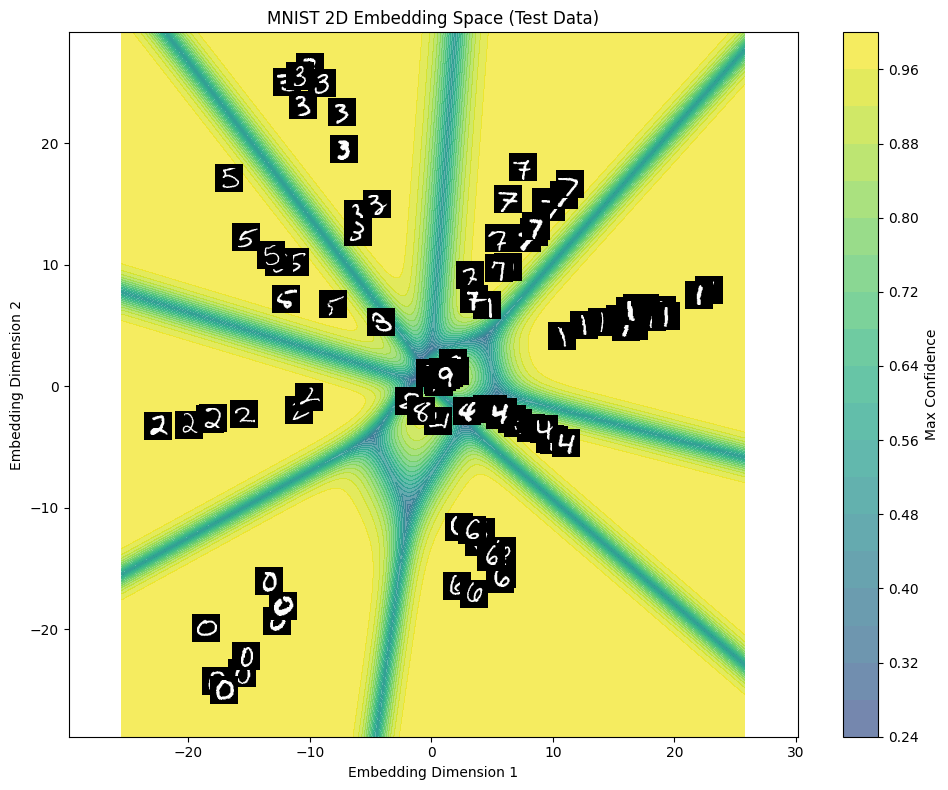

In [9]:
# Load the best saved model 
best_model = load_model(config).to(device)

print("Generating embedding space visualization...")

# We use test_loader so we visualize data the model has not memorized
visualize_embedding_space(
    model=best_model,
    data_loader=test_loader,
    config=config,
    title="MNIST 2D Embedding Space (Test Data)"
)

# Save image
save_path = "mnist_embedding_space.png"
plt.savefig(save_path, dpi=300, bbox_inches='tight')
print(f"Successfully saved plot to {save_path}")

### Extracting Weight Matrix and Bias from Final Layer

In [10]:
W = best_model.classifier.weight.data.cpu().numpy()
b = best_model.classifier.bias.data.cpu().numpy()

print("--- Learned Weight Matrix W ---")
print(W)
print("\n--- Learned Bias b ---")
print(b)

--- Learned Weight Matrix W ---
[[-1.2061276  -1.8035115 ]
 [ 1.9763994   0.7839605 ]
 [-2.0317621  -0.29581884]
 [-0.43313673  1.9908679 ]
 [ 1.5801383  -0.7450622 ]
 [-1.6222014   1.0636926 ]
 [ 0.46574557 -2.0399995 ]
 [ 0.7346243   1.9034941 ]
 [-0.46143642 -1.4168581 ]
 [ 0.99957573  0.5611711 ]]

--- Learned Bias b ---
[-2.11072    -1.6390058   0.17702323 -0.87499756 -0.38430005  0.09853486
 -1.3239601  -0.6161469   3.1443176   3.5292418 ]


## Part 3b

### Loading clothing items dataset

Generating OOD embedding space visualization...


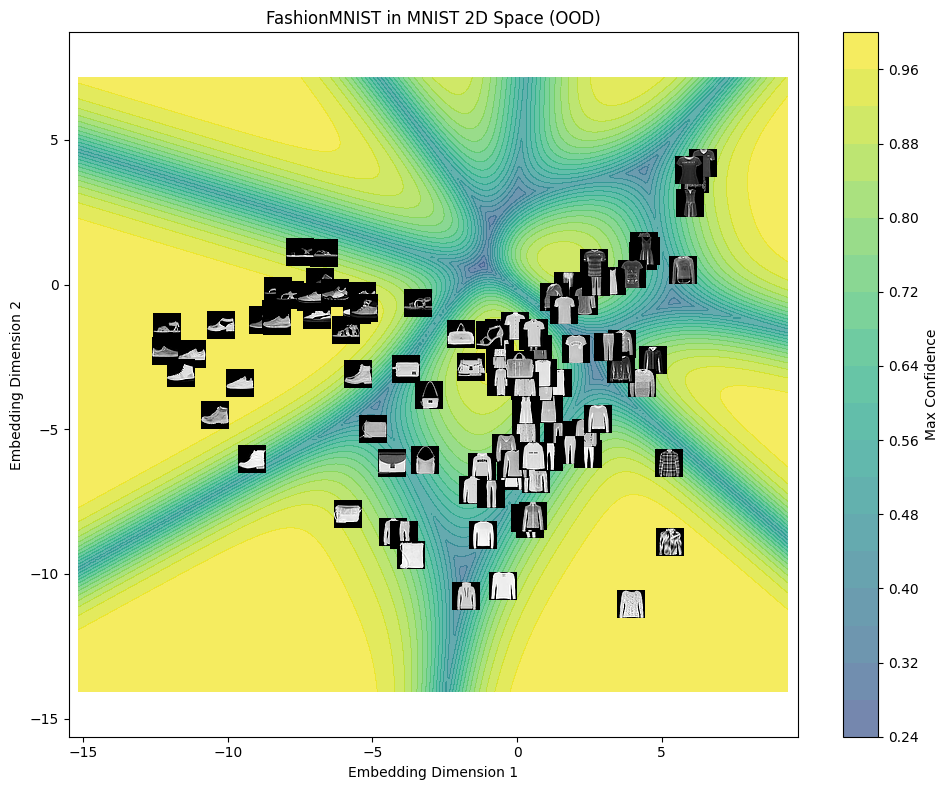

In [11]:
import matplotlib.pyplot as plt
import torchvision.datasets as datasets

# Download FashionMNIST dataset and throw away train_loader 
_, ood_loader = create_data_loaders(datasets.FashionMNIST, config)

print("Generating OOD embedding space visualization...")
visualize_embedding_space(
    model=best_model,
    data_loader=ood_loader,
    config=config,
    title="FashionMNIST in MNIST 2D Space (OOD)"
)

plt.savefig("fashion_mnist_ood_space.png", dpi=300, bbox_inches='tight')

### Plotting Softmax Histogram

Calculating confidence scores for MNIST (In-Distribution)...
Calculating confidence scores for FashionMNIST (Out-of-Distribution)...


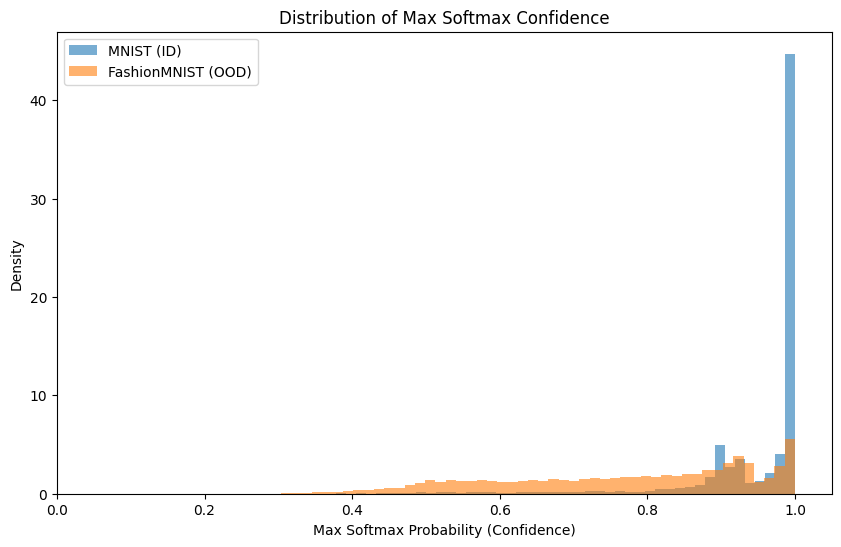

In [12]:
import torch.nn.functional as F

def get_max_softmax_scores(model, data_loader, device):
    
    # Ensure the model is in testing mode
    model.eval()
    max_scores = []

    # Throw away memory used for gradient computation since it is not required for testing
    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            scores = model(inputs)

            # Apply softmax to get probabilities
            probs = F.softmax(scores, dim=1)

            # Take the highest probability for each image
            max_prob, _ = torch.max(probs, dim=1)
            max_scores.extend(max_prob.cpu().numpy())
    
    return np.array(max_scores)

print("Calculating confidence scores for MNIST (In-Distribution)...")
mnist_scores = get_max_softmax_scores(best_model, test_loader, config.device)

print("Calculating confidence scores for FashionMNIST (Out-of-Distribution)...")
fashion_scores = get_max_softmax_scores(best_model, ood_loader, config.device)

# Plotting the Histogram
plt.figure(figsize=(10, 6))
# Plot MNIST scores in blue
plt.hist(mnist_scores, bins=50, alpha=0.6, label='MNIST (ID)', density=True)
# Plot FashionMNIST scores in orange
plt.hist(fashion_scores, bins=50, alpha=0.6, label='FashionMNIST (OOD)', density=True)

plt.title('Distribution of Max Softmax Confidence')
plt.xlabel('Max Softmax Probability (Confidence)')
plt.ylabel('Density')
plt.legend()
plt.xlim(0, 1.05)

plt.savefig("softmax_histogram.png", dpi=300, bbox_inches='tight')

### Custom OOD Detector

Calculating class means from MNIST training data...
Calculating distance scores for MNIST test data...
Calculating distance scores for FashionMnist (OOD)...


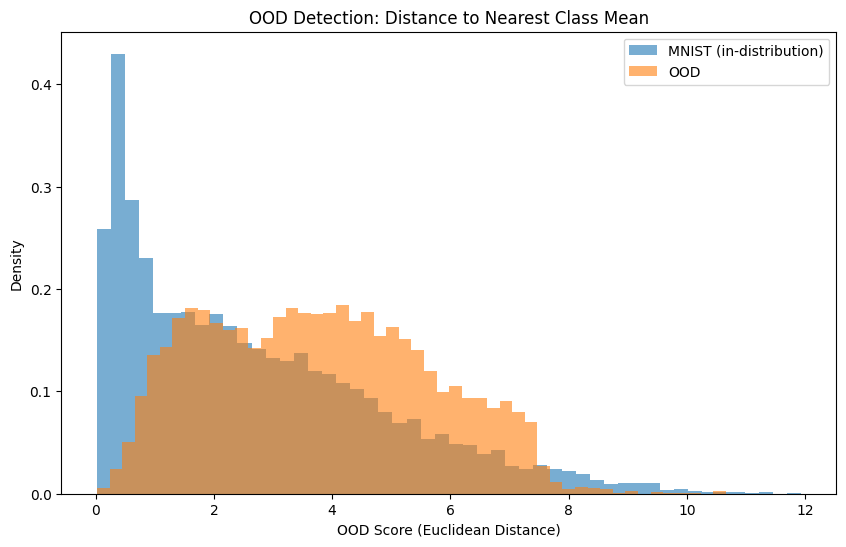

In [15]:
def compute_class_means(model, train_loader, device, num_classes=10):

    # Set to evaluation mode and not for training
    model.eval()
    class_sums = torch.zeros((num_classes, 2)).to(device)
    class_counts = torch.zeros(num_classes).to(device)

    with torch.no_grad():
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            # Get 2D coordinates, not the final probabilities
            coordinate = model.get_embeddings(inputs)

            # Add coordinates to running total for each class
            for c in range(num_classes):
                mask = (targets == c)
                if mask.sum() > 0:
                    class_sums[c] += coordinate[mask].sum(dim=0)
                    class_counts[c] += mask.sum()

    # Unsqueeze is used to fix the shape to match
    class_means = class_sums / class_counts.unsqueeze(1)
    return class_means

def compute_ood_scores(model, data_loader, class_means, device):

    # Set to evaluation mode and not for training
    model.eval()
    ood_scores = []

    with torch.no_grad():
        for inputs, _ in data_loader:
            inputs = inputs.to(device)
            coordinate = model.get_embeddings(inputs)

            # torch.cdist computes Euclidean distance from every coordinate to every class mean
            distances = torch.cdist(coordinate, class_means)

            # Keep only shorest distance for each image
            min_distances, _ = torch.min(distances, dim=1)
            ood_scores.extend(min_distances.cpu().numpy())

    return np.array(ood_scores)

# Get parameters from training data only 
print("Calculating class means from MNIST training data...")
class_means = compute_class_means(best_model, train_loader, config.device)

# Score the datasets
print("Calculating distance scores for MNIST test data...")
mnist_distance_scores = compute_ood_scores(best_model, test_loader, class_means, config.device)

print ("Calculating distance scores for FashionMnist (OOD)...")
fashion_distance_scores = compute_ood_scores(best_model, ood_loader, class_means, config.device)

# Plot the histogram
plt.figure(figsize=(10, 6))
# Plot MNIST scores in blue
plt.hist(mnist_distance_scores, bins=50, alpha=0.6, label='MNIST (in-distribution)', density=True)
# Plot FashionMNIST scores in orange
plt.hist(fashion_distance_scores, bins=50, alpha=0.6, label='OOD', density=True)

plt.title('OOD Detection: Distance to Nearest Class Mean')
plt.xlabel('OOD Score (Euclidean Distance)')
plt.ylabel('Density')
plt.legend()

plt.savefig("ood_distance_histogram.png", dpi=300, bbox_inches='tight')

# Question 4: Support Vector Machines

In [ ]:
# Rishank